In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve


In [ ]:
n=5000
df=pd.DataFrame({
    "customer_id":[F"CUST_{i:04d}"for i in range(1,n+1)],
    "age":np.random.randint(18,76,n),
    "gender":np.random.choice(["Male","Female","Other"],n),
    "tenure_months":np.random.randint(1,24,n),
})
df.head()

,customer_id,age,gender,tenure_months
0,CUST_0001,56,Male,16
1,CUST_0002,69,Female,7
2,CUST_0003,46,Male,16
3,CUST_0004,32,Female,3
4,CUST_0005,60,Male,16


In [ ]:
df["contract_type"]=np.random.choice(['Month-to-Month','One year','Two year'],n,p=(0.6,0.25,0.15))
df['payment_method']=np.random.choice(['Electronic check','Mailed check','Bank transfer','Credit card'],n,p=(0.35,0.25,0.20,0.20))
df['monthly_charges']=np.round(np.random.uniform(20,150,n))
df['total_charges']=(df['monthly_charges']*df['tenure_months']+np.random.normal(0,50,n)).round(2)
df['internet_service']=np.random.choice(['No','DSL','Fiber optic'],n,p=(0.3,0.5,0.2))
df["online_security"] = np.random.choice(["Yes", "No"], n, p=[0.5, 0.5])
df["tech_support"] = np.random.choice(["Yes", "No"], n, p=[0.5, 0.5])
df["streaming_services"] = np.random.choice(["Yes", "No"], n)
df["phone_service"] = np.random.choice(["Yes", "No"], n)
df["num_complaints"] = np.random.randint(0, 11, n)
df["customer_service_calls"] = np.random.randint(0, 16, n)
df.head()




,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,internet_service,online_security,tech_support,streaming_services,phone_service,num_complaints,customer_service_calls
0,CUST_0001,56,Male,16,Month-to-Month,Mailed check,146.0,2280.16,No,Yes,Yes,Yes,Yes,3,9
1,CUST_0002,69,Female,7,Month-to-Month,Mailed check,132.0,928.79,No,No,No,Yes,No,0,8
2,CUST_0003,46,Male,16,Two year,Bank transfer,47.0,807.47,No,No,Yes,Yes,No,0,13
3,CUST_0004,32,Female,3,Month-to-Month,Credit card,114.0,372.80,DSL,Yes,Yes,No,No,5,14
4,CUST_0005,60,Male,16,Month-to-Month,Bank transfer,58.0,986.70,DSL,Yes,No,Yes,Yes,6,0


In [ ]:
churn_score = np.zeros(n)
churn_score = np.zeros(n)
churn_score += np.where(df["contract_type"] == "Month-to-month", 1.0, 0)
churn_score += np.where(df["contract_type"] == "One year", 0.3, 0)
churn_score += df["num_complaints"] * 0.15
churn_score += df["customer_service_calls"] * 0.08
churn_score -= df["tenure_months"] * 0.03
churn_score += np.where(df["tech_support"] == "No", 0.7, 0)
churn_score += np.where(df["payment_method"] == "Electronic check", 0.6, 0)
churn_score -= 2.7
churn_score[:10]

,num_complaints
0,-2.01
1,-1.57
2,-2.14
3,-0.92
4,-1.58
5,-0.88
6,-0.59
7,0.43
8,-1.92
9,-1.39


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

churn_prob = sigmoid(churn_score)
churn_prob[:10]

,num_complaints
0,0.118157
1,0.172216
2,0.105269
3,0.284958
4,0.170795
5,0.293178
6,0.356635
7,0.605874
8,0.127862
9,0.199408


In [ ]:
df["churn"] = np.random.binomial(1, churn_prob)
df["churn"].mean()

np.float64(0.2762)

In [ ]:
df.to_csv("telecom_churn_synthetic.csv", index=False)

In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
tenure_months,0
contract_type,0
payment_method,0
monthly_charges,0
total_charges,0
internet_service,0
online_security,0


In [ ]:
df.describe()

,age,tenure_months,monthly_charges,total_charges,num_complaints,customer_service_calls,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,46.672800,12.081800,85.231400,1028.937634,4.905600,7.569200,0.276200
std,16.630005,6.583417,37.661125,766.463045,3.174572,4.604764,0.447162
min,18.000000,1.000000,20.000000,-75.000000,0.000000,0.000000,0.000000
25%,32.000000,6.000000,53.000000,420.050000,2.000000,4.000000,0.000000
50%,47.000000,12.000000,85.000000,838.780000,5.000000,8.000000,0.000000
75%,61.000000,18.000000,118.250000,1497.957500,8.000000,12.000000,1.000000
max,75.000000,23.000000,150.000000,3469.790000,10.000000,15.000000,1.000000


Text(0.5, 1.0, 'churn distribution')

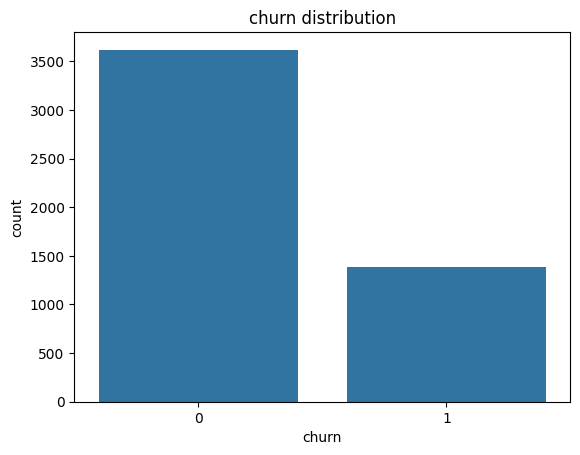

In [ ]:
sns.countplot(x='churn',data=df)
plt.title('churn distribution')

Text(0.5, 1.0, 'tenure vs churn')

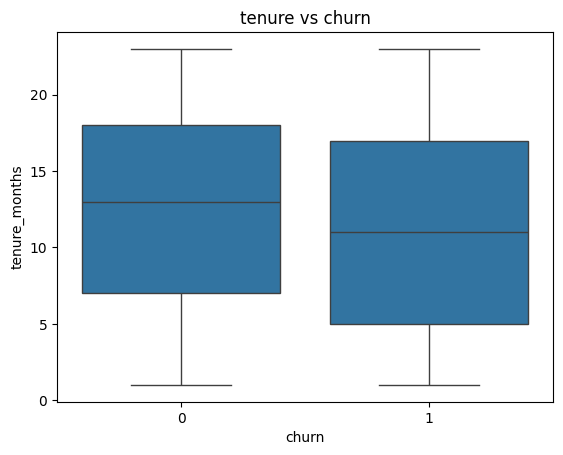

In [ ]:
sns.boxplot(x='churn',y='tenure_months',data=df)
plt.title('tenure vs churn')

Text(0.5, 1.0, 'complaints vs churn')

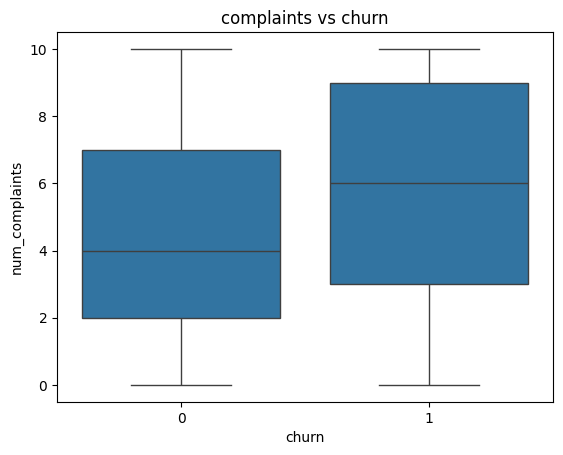

In [ ]:
sns.boxplot(x='churn',y='num_complaints',data=df)
plt.title('complaints vs churn')

Text(0.5, 1.0, 'monthly charges vs churn')

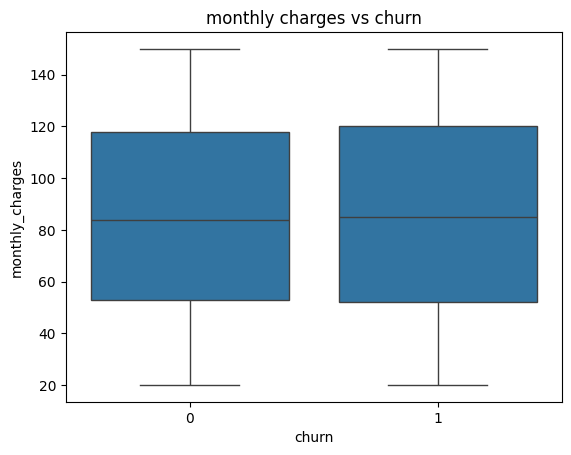

In [ ]:
sns.boxplot(x='churn',y='monthly_charges',data=df)
plt.title('monthly charges vs churn')

Text(0.5, 1.0, 'churn vs contract')

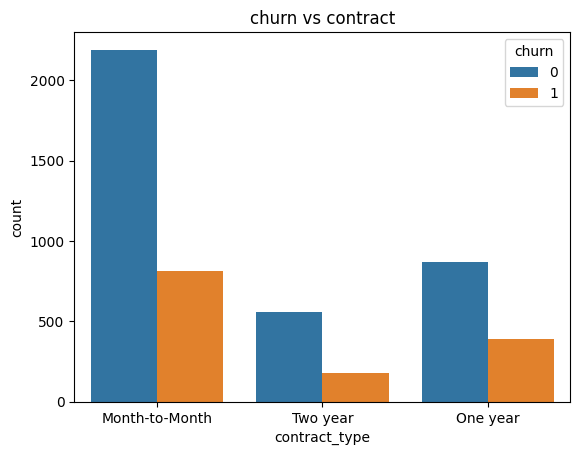

In [ ]:
sns.countplot(x="contract_type", hue="churn", data=df)
plt.title("churn vs contract")

<Axes: xlabel='payment_method', ylabel='count'>

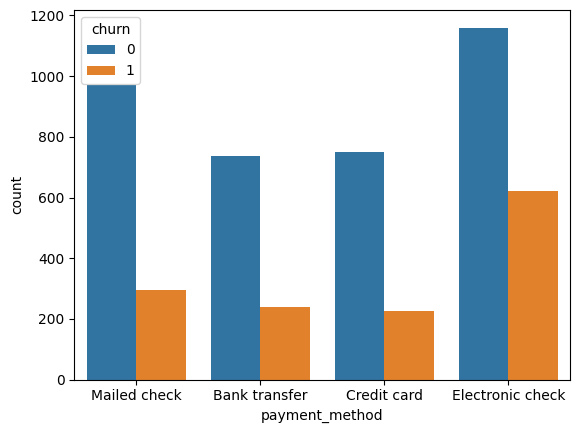

In [ ]:
sns.countplot(x="payment_method", hue="churn", data=df)

<Axes: xlabel='tech_support', ylabel='count'>

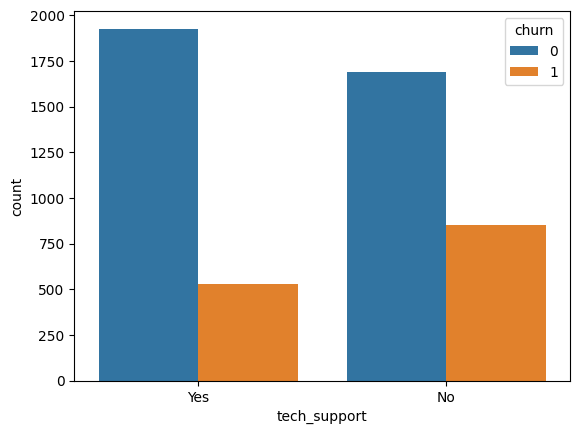

In [ ]:
sns.countplot(x="tech_support", hue="churn", data=df)

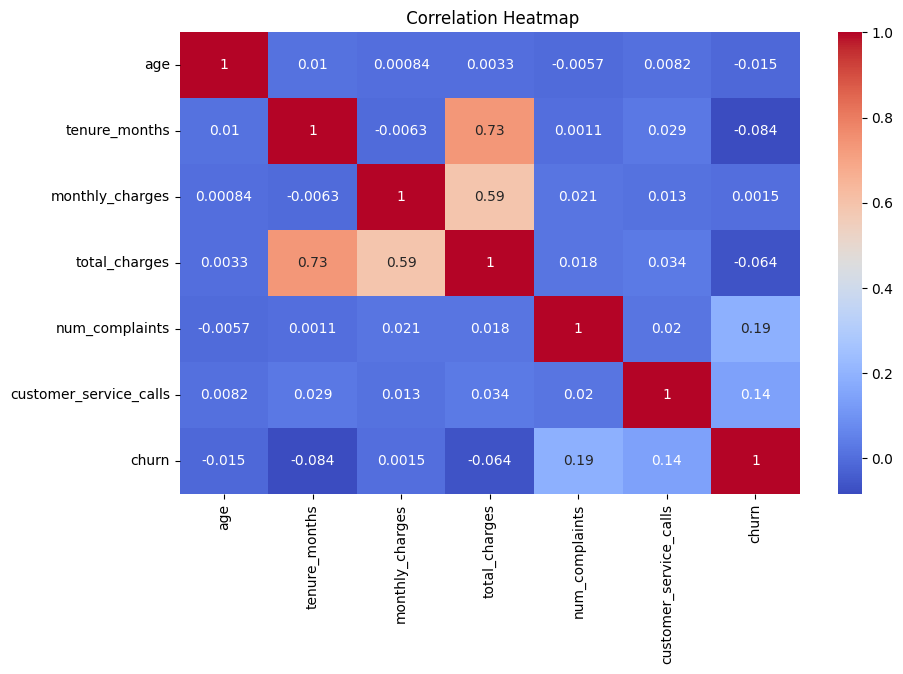

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title(" Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop(columns=["churn","customer_id"])
y = df["churn"]

X = pd.get_dummies(X, drop_first=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_test

,churn
2540,1
1336,0
4950,1
4118,0
4501,0
...,...
4775,0
1878,0
4598,1
321,0


In [ ]:
y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

array([1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[463 261]
 [ 98 178]]
              precision    recall  f1-score   support

           0       0.83      0.64      0.72       724
           1       0.41      0.64      0.50       276

    accuracy                           0.64      1000
   macro avg       0.62      0.64      0.61      1000
weighted avg       0.71      0.64      0.66      1000



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[638  86]
 [187  89]]
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       724
           1       0.51      0.32      0.39       276

    accuracy                           0.73      1000
   macro avg       0.64      0.60      0.61      1000
weighted avg       0.70      0.73      0.71      1000



In [ ]:
from sklearn.metrics import roc_auc_score
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_pred_rf = (y_prob_rf > 0.35).astype(int)

roc_auc_score(y_test, y_prob_rf)

np.float64(0.6871496917287212)

In [ ]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
y_pred_log = (y_prob_log > 0.45).astype(int)

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[388 336]
 [ 64 212]]
              precision    recall  f1-score   support

           0       0.86      0.54      0.66       724
           1       0.39      0.77      0.51       276

    accuracy                           0.60      1000
   macro avg       0.62      0.65      0.59      1000
weighted avg       0.73      0.60      0.62      1000



In [ ]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
roc_auc_score(y_test, y_prob_log)

np.float64(0.7112909360237009)

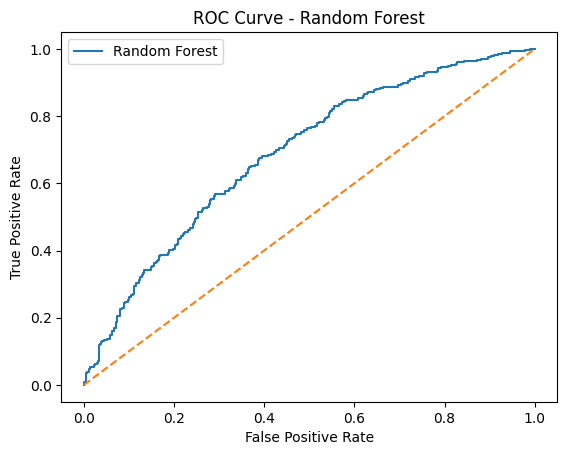

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

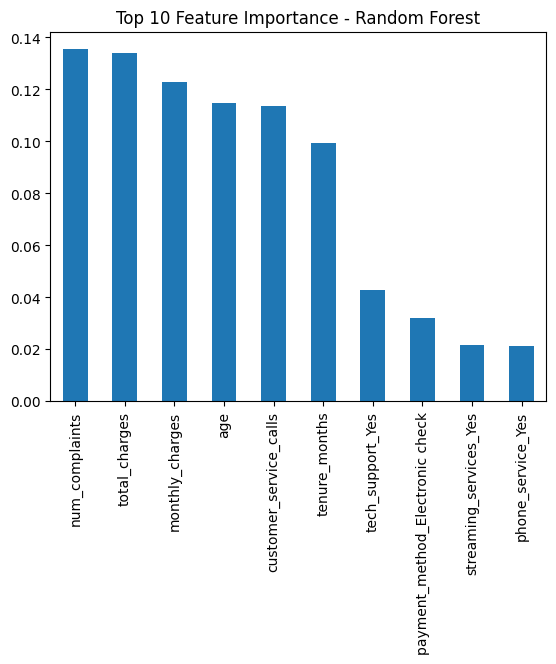

In [ ]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance - Random Forest")
plt.show()

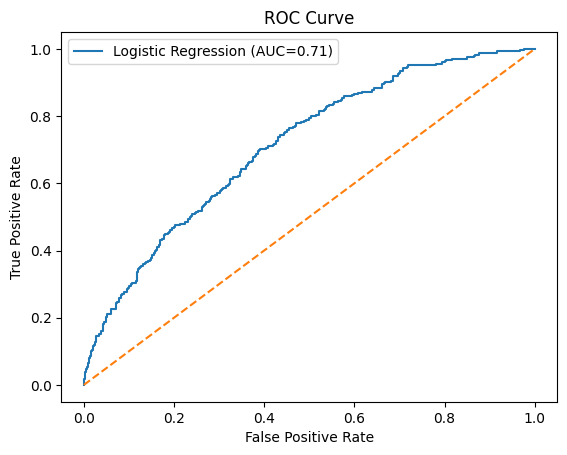

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_log)

plt.plot(fpr, tpr, label="Logistic Regression (AUC=0.71)")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
coeff = pd.Series(log_model.coef_[0], index=X.columns)
coeff.sort_values(ascending=False).head(10)

,0
num_complaints,0.452476
payment_method_Electronic check,0.281644
customer_service_calls,0.281349
contract_type_One year,0.120219
monthly_charges,0.096518
phone_service_Yes,0.054122
gender_Other,0.048863
internet_service_Fiber optic,0.039105
internet_service_No,0.025939
streaming_services_Yes,0.003734


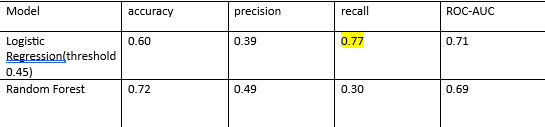


# **Model Evaluation**
  Two models(Logistic Regression and Random forest) were evaluated after predicting customer churn.Initially had a recall of 0.64 but after threshhold tuning(0.5 to 0.45) recall became 0.71 making the model correctly identify majority of churning customers.But precision decreased due to a lot of false positives.However in customer churn prediction high recall is desirable because identifying risk customers is more important than false positives
 Although the Random Forest model had a better accuracy, it performed poorly in the detection of churn customers, as indicated by the lower recall. Thus, the use of Logistic Regression with threshold tuning is more appropriate for the detection of churn customers, as it focuses on the identification of the customers at risk of leaving the business, which is the main purpose of churn management.

# **Important metrics**
  Recall is a more important metric for evaluating the performance of a churn prediction model. Recall evaluates the model’s ability to identify actual customers who churn. Failing to identify a customer who churns means the business loses revenue since it will not take any measures to keep the customer.

Precision is also an important metric for evaluating the performance of a model for predicting customer churn. Precision evaluates the model’s ability to identify the actual customers who churn. Low precicion means the business will incur unnecessary expenses to retain customers who were not likely to churn.

Lastly, ROC-AUC helps to evaluate the model’s ability to differentiate between actual customers who chun and those who do not. A high ROC-AUC means the model can differentiate between high-risk customers who churn and those who do not.

In conclusion, the most important metric for evaluating the performance of a model for predicting customer churn is recall. This is because the model’s ability to identify as many potential customers who churn as possible allows the business to take proactive steps to retain them.

# **Model Selection**
  Random Forest had accuracy of 0.72 but very low recall of 0.30,which implies it failed to detect most churn customer.In customer churn prediction recall is an important metric so this model was rejected.Missing a churn customers means a lot of loss in revenue but false positives(incorrectly flagging loyal customers as churn) would not incur that much loss.However Logistic Regression model had a recall of 0.71 much higher than the other model but low precision(0.39) buut its a necessary tradeoff the company has to make.Identifying actual churn customers should bee the priority and false positives are tiny sacrifices the company has to make
  
> So,Logistic Regression with threshhold tuning is the more preferred model.
RECALL=0.71,PRECISION=0.39,ROC-AUC=0.71




# **Key Business Insights**


1.   Customers with higher number of complaints are more likely to churn
2.   Frequent customer service  calls lead to churn


1.   Customers having month-month plan were more likely to churn instead of long term ones

1.   Customers having short tenure are in the risk of churning


1.   Customers using electronic check payment methods show higher churn risk compared to other payment
2. Higher monthly charges and total spending are associated with increased churn probability.






# *Business Decisions*


1.   Identify customers with higher churn probability and offer the discounts to keep them as customers.
2.   Improve the customer service quality to provide necessary steps to reduce complaints and prevent future churns.


1.   Reduce price of long term plans to encourage customers to shift from month-month to long term contracts.Advertisements of long term plans should be given more priority
2.  Customers with multiple complaints should be flagged automatically and assigned priority support to resolve issues quickly before they decide to leave.


1.   Customer service training for employees
2.   Loyalty reward programs





